Best epoch:
    epoch  avg_loss  learning_rate
3      3  0.024215          0.001


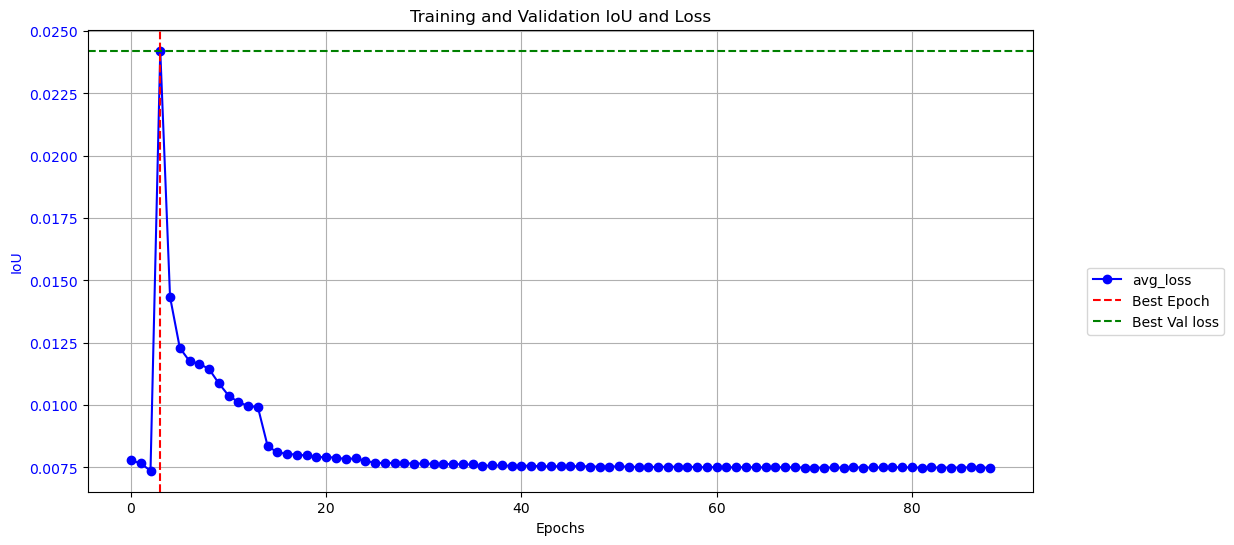

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
def training_plot(training_summary_route):
    df = pd.read_csv(training_summary_route)

    best_epoch = df[df.avg_loss == df.avg_loss.max()]
    print("Best epoch:\n", best_epoch)

    fig, ax1 = plt.subplots(figsize=(14, 6))  # Wider figure

    # IoU plots
    ax1.plot(df.index, df['avg_loss'], label='avg_loss', marker='o', color='blue')
    ax1.axvline(x=best_epoch.index[0], color='red', linestyle='--', label='Best Epoch')
    ax1.axhline(y=best_epoch.avg_loss.values[0], color='green', linestyle='--', label='Best Val loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('IoU', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True)

    # Combine legends and place outside right
    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1, labels1,
               loc='upper left', bbox_to_anchor=(1.05, 0.5))  # Shift legend further right

    plt.title('Training and Validation IoU and Loss')
    plt.subplots_adjust(right=0.8)  # Give more room on the right
    plt.show()
    
training_plot("models/weights/autoencoder/autoencoder_training_log.csv")

In [11]:
# Standard libraries
import os
import random

# Numerical and Data Processing
import numpy as np  # Linear algebra
import pandas as pd  # Data processing, CSV file I/O (e.g., pd.read_csv)

# PyTorch Data Handling
from torch.utils.data import Dataset, DataLoader

# OpenCV for image processing
import cv2

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Custom utilities and configuration
from utils import visualize, analyze
from data_input import test_dataset,val_dataset,train_dataset
from config import PATH_TEST, PATH_TRAINVAL, SEED, BATCH_SIZE

# NN Framework
import torch
from model import UNet
import torchviz

# Set random seed for reproducibility
random.seed(SEED)


test_image_path = os.path.join(PATH_TEST, 'color/')
test_mask_path = os.path.join(PATH_TEST, 'label/')
test_image_list_orig = sorted(os.listdir(test_image_path))
test_mask_list_orig = sorted(os.listdir(test_mask_path))

trainval_image_path = os.path.join(PATH_TRAINVAL, 'color/')
trainval_mask_path = os.path.join(PATH_TRAINVAL, 'label/')
trainval_image_list_orig = sorted(os.listdir(trainval_image_path))
trainval_mask_list_orig = sorted(os.listdir(trainval_mask_path))
image_list = [trainval_image_path+i for i in trainval_image_list_orig]
mask_list = [trainval_mask_path+i for i in trainval_mask_list_orig]
len(trainval_mask_list_orig)

3673

In [12]:
# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Example: Fetch a batch
images, masks = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}, Mask batch shape: {masks.shape}")

Image batch shape: torch.Size([4, 3, 224, 224]), Mask batch shape: torch.Size([4, 224, 224])


In [13]:
from model import Autoencoder,UNet
import torch.optim as optim
import torch.nn as nn

autoencoder = Autoencoder(input_channels=3, n_filters=64)

unet = UNet(input_channels=3, n_filters=64, n_classes=4)


In [14]:
import torch
import clip
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import transforms
epochs = 20
learning_rate = 0.001

# Define Loss and Optimizer
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, unet.parameters()), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()
# Define device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
unet.to(device)

# Load CLIP
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

# Replace original train loop
for epoch in range(epochs):
    unet.train()
    train_loss = 0

    for images, masks in train_dataloader:
        images, masks = images.to(device), masks.to(device)
        print("CLIP Features Shape:", images.shape)
        break
        # Preprocess for CLIP
        # [B, C, H, W] → [B, 3, 224, 224] + Normalize
        # clip_inputs = torch.stack([
        #     clip_preprocess(transforms.ToPILImage()(img.cpu())).to(device)
        #     for img in images
        # ])

        # with torch.no_grad():
        #     clip_features = clip_model.encode_image(clip_inputs)  # shape [B, 512]

        # # You could log this or pass it to a head network, etc.
        # # For now, we continue training U-Net normally

        # # Forward pass U-Net
        # outputs = unet(images)
        # loss = criterion(outputs, masks)

    #     optimizer.zero_grad()
    #     loss.backward()
    #     optimizer.step()

    #     train_loss += loss.item()

    # avg_train_loss = train_loss / len(train_dataloader)
    # print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}")


CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])
CLIP Features Shape: torch.Size([4, 3, 224, 224])


In [15]:
import torch
import clip
from PIL import Image

device = "mps" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load('RN101', device=device)

image = preprocess(Image.open("Dataset/TrainVal/color/Abyssinian_1.jpg")).unsqueeze(0).to(device)
text = clip.tokenize(["a diagram", "a dog", "a cat"]).to(device)

# Load CLIP
clip_model, clip_preprocess = clip.load('RN101', device=device)
clip_model.eval()

with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    
    logits_per_image, logits_per_text = model(image, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

print("Label probs:", probs)  # prints: [[0.9927937  0.00421068 0.00299572]]

Label probs: [[0.00667605 0.00887665 0.98444724]]


In [16]:
image_features.shape

torch.Size([1, 512])

In [8]:
from torchvision import transforms

for images, masks in train_dataloader:
    images, masks = images.to(device), masks.to(device)

    # Preprocess for CLIP
    # [B, C, H, W] → [B, 3, 224, 224] + Normalize
    clip_inputs = torch.stack([
        clip_preprocess(transforms.ToPILImage()(img.cpu())).to(device)
        for img in images
    ])

    with torch.no_grad():
        clip_features = clip_model.encode_image(clip_inputs)  # shape [B, 512]

    print("CLIP Features Shape:", clip_features.shape)
    break

CLIP Features Shape: torch.Size([4, 512])


In [9]:
clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

In [10]:
# Define training parameters
retrain = True
epochs = 10
learning_rate = 0.001
batch_size = 8  # Adjust based on your GPU memory
best_val_loss = float("inf")

# Move model to GPU (if available)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# unet.to(device)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
unet.to(device)

# Define DataLoaders
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Define Loss and Optimizer
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, unet.parameters()), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

if retrain:
    print("Training U-Net for segmentation...")
    for epoch in range(epochs):
        # ---------------------------
        # Training Phase
        # ---------------------------
        unet.train()
        train_loss = 0
        for images, masks in train_dataloader:
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = unet(images)
#             loss = criterion(outputs, masks)

#             # Backward pass
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             train_loss += loss.item()

#         avg_train_loss = train_loss / len(train_dataloader)

#         # ---------------------------
#         # Validation Phase
#         # ---------------------------
#         unet.eval()
#         val_loss = 0
#         with torch.no_grad():
#             for images, masks in val_dataloader:
#                 images, masks = images.to(device), masks.to(device)

#                 outputs = unet(images)
#                 loss = criterion(outputs, masks)
#                 val_loss += loss.item()

#         avg_val_loss = val_loss / len(val_dataloader)

#         # Print loss for this epoch
#         print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

#         # Save the best model based on validation loss
#         if avg_val_loss < best_val_loss:
#             best_val_loss = avg_val_loss
#             torch.save(unet.state_dict(), f"weights/autoencoder/autoencoder_unet/unet_best_{best_val_loss:.4f}.pth")
#             print("Best model saved!")

# print("Training complete!")


Training U-Net for segmentation...


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


In [57]:
import clip
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize


clip_model, preprocess = clip.load("RN101", device=device)
clip_encoder = clip_model.visual


class CLIPResNetFeatureExtractor(nn.Module):
    def __init__(self, clip_encoder):
        super().__init__()
        self.clip_encoder = clip_encoder
        self.feature_map = None

        def save_features(module, input, output):
            self.feature_map = output

        # Find last conv layer before attention pool
        self.clip_encoder.layer4.register_forward_hook(save_features)

    def forward(self, x):
        _ = self.clip_encoder(x)  # run through entire CLIP encoder
        return self.feature_map  # output from layer4 (shape [B, 2048, 7, 7])



class CLIPResnetSegmentationModel(nn.Module):
    def __init__(self, clip_encoder, num_classes):
        super().__init__()
        self.encoder = CLIPResNetFeatureExtractor(clip_encoder)
        for param in self.encoder.parameters():
            param.requires_grad = False

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 4, 2, 1),  # 7 → 14
            nn.ReLU(),
            nn.ConvTranspose2d(1024, 512, 4, 2, 1),   # 14 → 28
            nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),    # 28 → 56
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),    # 56 → 112
            nn.ReLU(),
            nn.ConvTranspose2d(128, num_classes, 4, 2, 1)  # 112 → 224
        )

    def forward(self, x):
        features = self.encoder(x)  # [B, 2048, 7, 7]
        return self.decoder(features)




In [58]:
def compute_iou(preds, labels, num_classes):
    ious = []
    preds = torch.argmax(preds, dim=1)
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (labels == cls)
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union == 0:
            ious.append(float('nan'))  # ignore class if not present
        else:
            ious.append(intersection / union)
    return np.nanmean(ious)


In [59]:
import numpy as np
from tqdm import tqdm

def train_segmentation_model(model, dataloader_train, dataloader_val, num_classes, epochs, lr, device):
    model.to(device)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_iou = 0

        for x, y in tqdm(dataloader_train, desc=f"Epoch {epoch+1}/{epochs}"):
            x, y = x.to(device), y.to(device)

            preds = model(x)
            loss = criterion(preds, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_iou += compute_iou(preds.detach().cpu(), y.cpu(), num_classes)

        avg_loss = total_loss / len(dataloader_train)
        avg_iou = total_iou / len(dataloader_train)
        print(f"[Train] Epoch {epoch+1} | Loss: {avg_loss:.4f} | IoU: {avg_iou:.4f}")

        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = 0
            val_iou = 0
            for x_val, y_val in dataloader_val:
                x_val, y_val = x_val.to(device), y_val.to(device)
                preds_val = model(x_val)
                loss_val = criterion(preds_val, y_val)
                val_loss += loss_val.item()
                val_iou += compute_iou(preds_val.cpu(), y_val.cpu(), num_classes)

        avg_val_loss = val_loss / len(dataloader_val)
        avg_val_iou = val_iou / len(dataloader_val)
        print(f"[Val]   Epoch {epoch+1} | Loss: {avg_val_loss:.4f} | IoU: {avg_val_iou:.4f}")


In [60]:
import clip
clip_model, preprocess = clip.load("RN101", device=device)
clip_encoder = clip_model.visual
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

clip_seg_model = CLIPResnetSegmentationModel(clip_encoder, num_classes=4).to(device)

train_segmentation_model(
    model=clip_seg_model,
    dataloader_train=train_dataloader,
    dataloader_val=val_dataloader,
    num_classes=4,
    epochs=10,
    lr=1e-4,
    device=device
)


Epoch 1/10: 100%|██████████| 735/735 [08:09<00:00,  1.50it/s]


[Train] Epoch 1 | Loss: 0.7787 | IoU: 0.3358


Corrupt JPEG data: premature end of data segment


[Val]   Epoch 1 | Loss: 0.5856 | IoU: 0.4647


Epoch 2/10: 100%|██████████| 735/735 [08:11<00:00,  1.50it/s]


...

[Train] Epoch 8 | Loss: 0.4664 | IoU: 0.5618


Corrupt JPEG data: premature end of data segment


[Val]   Epoch 8 | Loss: 0.4272 | IoU: 0.5744


Epoch 9/10:  59%|█████▉    | 433/735 [04:49<03:22,  1.49it/s]


KeyboardInterrupt: 

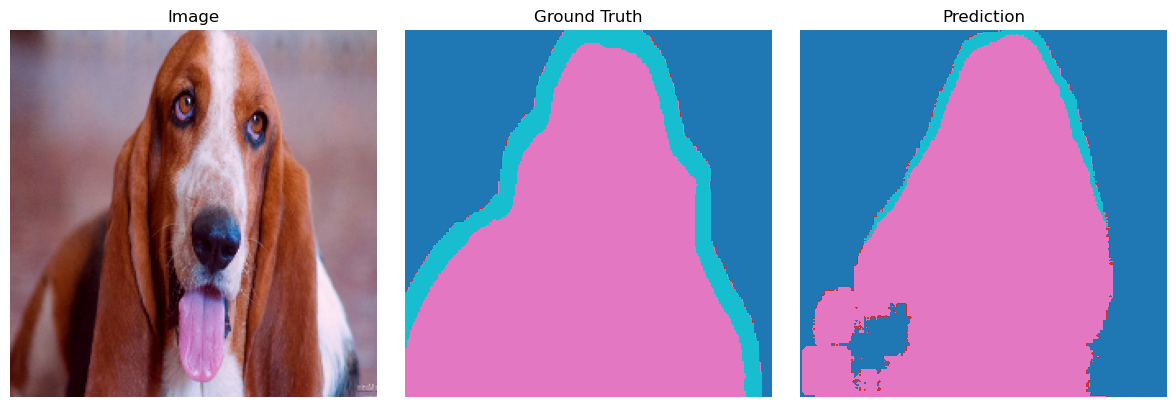

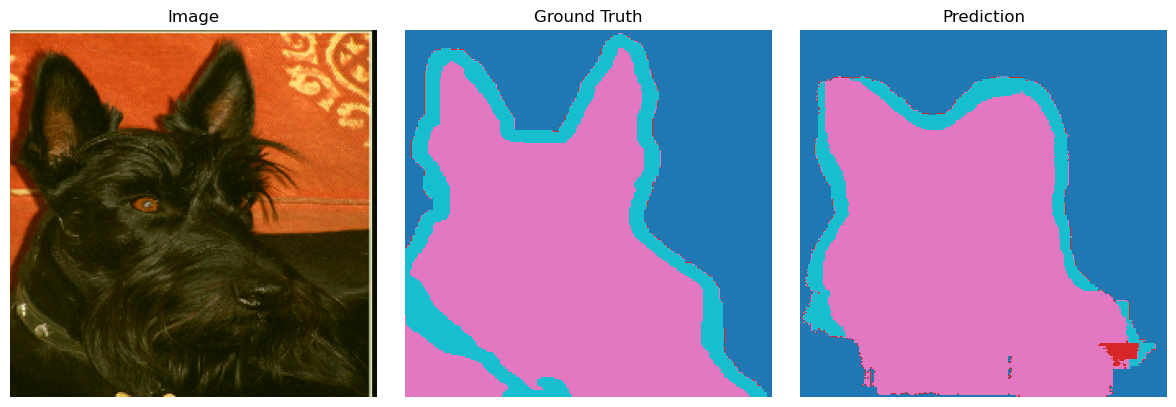

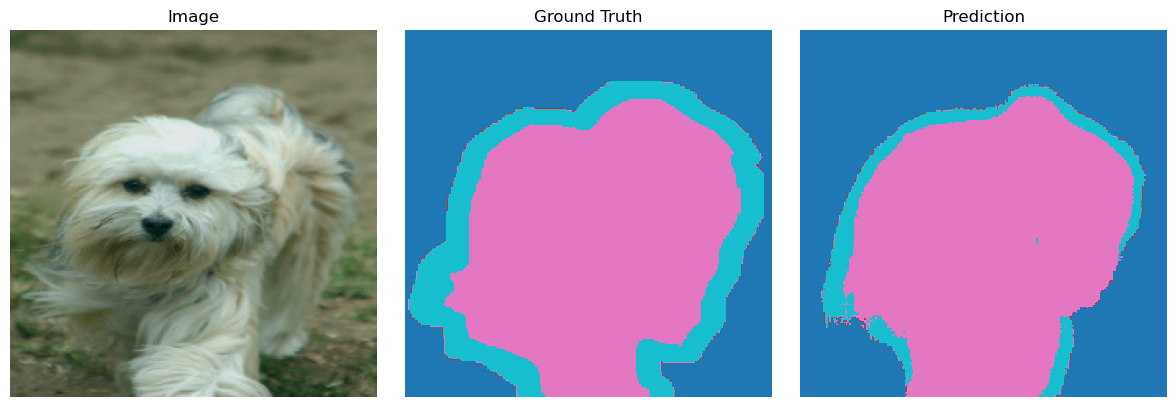

In [61]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, num_classes, device, num_samples=3):
    model.eval()
    cmap = plt.cm.get_cmap('tab10', num_classes)

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            preds = torch.argmax(preds, dim=1)

            for i in range(min(num_samples, x.shape[0])):
                image = x[i].cpu().permute(1, 2, 0).numpy()
                mask_true = y[i].cpu().numpy()
                mask_pred = preds[i].cpu().numpy()

                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(image)
                axs[0].set_title("Image")
                axs[1].imshow(mask_true, cmap=cmap, vmin=0, vmax=num_classes - 1)
                axs[1].set_title("Ground Truth")
                axs[2].imshow(mask_pred, cmap=cmap, vmin=0, vmax=num_classes - 1)
                axs[2].set_title("Prediction")

                for ax in axs:
                    ax.axis("off")
                plt.tight_layout()
                plt.show()
            break  # only visualize the first batch
visualize_predictions(clip_seg_model, val_dataloader, num_classes=4, device=device)
